### Initial Imports and Data Splits

In [1]:
# import statements --> SOME OF THESE MAY NOT BE NEEDED
%matplotlib inline 
import numpy as np 

from matplotlib import pyplot as plt 
from matplotlib.cm import get_cmap
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MultipleLocator
#from matplotlib.ticker import MaxNLocator
#import matplotlib.gridspec as gridspec
#import matplotlib.colors as mcolors
#import colorcet as cc
#from matplotlib.patches import Rectangle, FancyArrowPatch
#import matplotlib.ticker as ticker
#from mpl_toolkits.mplot3d import Axes3D
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#import mpl_scatter_density
#from astropy.visualization import LogStretch
#from astropy.visualization.mpl_normalize import ImageNormalize

#import h5py

#from astropy.io import fits,ascii,votable
#from astropy import units as u 
#from astropy import constants as const
#from astropy import table
#from astropy.cosmology import Planck15,FlatLambdaCDM
#from astropy.table import Table

#from sklearn.cluster import KMeans
#from sklearn import mixture
#from itertools import combinations
#from sklearn.neighbors import KNeighborsRegressor
#from sklearn.utils import check_array
#from sklearn.neighbors._base import _get_weights
#imports for TWO-NN
#import scipy
from sklearn import neighbors
#from sklearn import preprocessing

#import scipy.integrate
#from scipy.integrate import quad
#import numba
#from sklearn.datasets import load_digits
import umap
import umap.plot
from umap.umap_ import nearest_neighbors
import pandas as pd
#import plotly
import plotly.express as px

#imports for plotly graphing
#import plotly.graph_objects as go
#from plotly.subplots import make_subplots

import pickle

pd.set_option('display.max_columns', None)

#BRETT NOTEBOOK IMPORTS
from pathlib import Path

from importlib import reload
import utils
reload(utils)
from minisom import MiniSom

# imports from animation_simplified2 notebook
import seaborn as sns
sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})
import os
import copy

/Applications/anaconda3/envs/env1/lib/python3.11/site-packages/umap/plot.py:203: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit(nopython=False)


In [2]:
import umapz2

In [3]:
data = pd.read_parquet('umap_embeddings_260313.parquet')
spec95 = pd.read_parquet('spec95_ugrizyJH_maps_250819.parquet')
spec95 = spec95.drop(columns=['SOM-1', 'SOM-2', 'UMAP3D-1', 'UMAP3D-2', 'UMAP3D-3'])
spec95 = spec95[spec95['specz']>0.0]
spec95 = pd.merge(left=spec95[['ID', 'specz']], right=data, left_on='ID', right_on='ID')
spec95

,ID,specz,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,UMAPnn55-1,UMAPnn55-2,UMAPnn55-3,UMAPnn60-1,UMAPnn60-2,UMAPnn60-3,UMAPnn65-1,UMAPnn65-2,UMAPnn65-3,UMAPnn70-1,UMAPnn70-2,UMAPnn70-3,UMAPnn75-1,UMAPnn75-2,UMAPnn75-3,UMAPnn80-1,UMAPnn80-2,UMAPnn80-3,UMAPnn85-1,UMAPnn85-2,UMAPnn85-3
0,535,0.82589,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848,-2.395665,1.268724,-0.388012,-2.262672,1.251605,-0.195012,-2.171973,1.178506,-0.055983,-2.170027,1.110945,-0.026783,-2.116134,1.183956,0.063760,-2.010468,1.112640,0.093870,-1.935591,1.269083,0.215187
1,670,1.16549,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038,-1.242285,-0.418052,5.438861,-1.166276,-0.352745,5.568201,-1.132474,-0.339103,5.686192,-1.088242,-0.350635,5.607572,-1.074519,-0.339060,5.719284,-1.026085,-0.364025,5.754747,-0.913681,-0.267584,5.770304
2,692,0.30572,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,98.679499,0.078428,0.000908,133.665136,0.058089,0.000475,81.719072,0.032358,0.000524,83.615927,0.028347,0.000451,0.3269,0,NaN,29,0.29,9,5.000000e+09,0.4,1,-16.72223,-20.57175,-21.94677,10.35539,10.31772,10.39305,10.38281,0.19029,-10.190,23.602427,22.270727,21.097491,20.447285,20.039179,19.891197,19.341648,18.914433,18.584955,19.119191,19.094277,1.331700,1.173237,0.650205,0.408106,0.147982,0.549549,0.427216,6.988821,6.586997,2.660707,6.886271,6.639610,2.677922,6.848022,6.611507,2.725732,6.875618,6.572424,2.862262,6.841758,6.555278,2.937378,6.828689,6.606230,2.970417,6.804346,6.635503,3.050954
3,1143,0.80030,150.589033,1.889879,0,0.063290,0.003653,0.072636,0.254108,0.004009,0.016990,1.155916,0.005216,0.004662,4.069362,0.005549,0.001476,6.650530,0.009029,0.001461,8.661979,0.019250,0.002276,14.262715,0.022103,0.001680,23.028622,0.020338,0.001009,32.456397,0.027529,0.000926,NaN,NaN,NaN,26.183528,0.044004,0.002237,0.7986,0,NaN,28,0.64,1,2.000000e+09,0.0,0,-16.79230,-21.67922,-22.74348,10.34975,10.31558,10.38392,10.32480,-6.09950

In [4]:
splits = umapz2.data_split(photcat=data, speccat=spec95, valid_size=len(spec95), rs=41)

### UMAP Optimization Procedure:
1. UMAP-kNN-z k-value optimization, in a fixed UMAP embedding.

2. UMAP n_neighbors hyperparameter optimization, with fixed k-value

3. Select best values + "reasonable range" for k and n_neighbors. Pick 5 values covering each range and 
    run through testing with the other value fixed (spec-z-trained case only), (max-min)/metric as 
    uncertainty due to choice of that parameter in each redshift bin.

4. For fixed k and n_neighbors, run embeddings with 10-25 different random seeds and quantify uncertainty
    due to random seed in each redshift bin.
    
5. This covers uncertainties in UMAP-kNN-z due to embedding/optimization.
    Uncertainty due to finite test data can be calculated with 10-25 bootstrap samples of the size of the test set,
    with replacement. Measure all statistics and look at standard deviation in redshift bins.
    This is for fixed k, n_neighbors, and random seed.

### uncertainty due to k-value optimization

Based on our testing with the validation sample, 13 or 15 is the best option for k. Taking the position that a slightly larger k-value may be more advantageous in the final tests, which feature more 1.25x more training data, we will use k=15 for our n_neighbors optimization and later testing. We will take +/-15% of this value (13 and 17) and hold other parameters (n_neighbors, random seed) constant in order to quantify the uncertainty associated with choice of k-value.

In [5]:
valid=splits['valid'].copy()

In [6]:
valid

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,UMAPnn55-1,UMAPnn55-2,UMAPnn55-3,UMAPnn60-1,UMAPnn60-2,UMAPnn60-3,UMAPnn65-1,UMAPnn65-2,UMAPnn65-3,UMAPnn70-1,UMAPnn70-2,UMAPnn70-3,UMAPnn75-1,UMAPnn75-2,UMAPnn75-3,UMAPnn80-1,UMAPnn80-2,UMAPnn80-3,UMAPnn85-1,UMAPnn85-2,UMAPnn85-3
682744,888967,149.936450,2.785401,0,0.482169,0.008109,0.021217,0.556797,0.004353,0.008433,0.649724,0.005866,0.009340,0.815287,0.006075,0.008074,1.022175,0.009601,0.010115,1.516981,0.023160,0.015645,2.479349,0.054714,0.023929,3.181551,0.075771,0.027204,3.775385,0.057224,0.016556,5.577980,0.014766,0.003503,6.055261,0.017200,0.003780,1.5429,0,NaN,27,0.99,5,1.139000e+09,0.2,0,-19.84784,-21.53190,-22.12276,10.02579,9.89337,10.08403,10.03590,1.14004,-8.917,24.692001,24.535758,24.368177,24.121724,23.876187,23.447549,22.914156,22.643403,22.457597,22.033808,21.944668,0.156243,0.167580,0.246453,0.245537,0.428638,0.533394,0.270753,1.439148,3.688958,9.313959,1.442810,3.775632,9.351755,1.439867,3.747785,9.490368,1.454326,3.675086,9.452222,1.458698,3.668823,9.518856,1.452414,3.705678,9.563761,1.508997,3.737282,9.673626
705718,915989,150.389923,1.791782,0,0.300923,0.003346,0.013912,0.391560,0.003238,0.008863,0.729946,0.004244,0.005987,0.857738,0.004264,0.005368,0.908493,0.006994,0.008269,1.053736,0.015095,0.014646,1.133205,0.028540,0.027268,1.063807,0.038095,0.040864,1.151679,0.027239,0.025818,0.553292,0.012940,0.030942,0.312715,0.016622,0.070726,0.4445,0,NaN,30,0.00,1,3.210000e+08,0.0,0,-16.35030,-17.63879,-17.70557,8.08427,8.02849,8.19774,8.06536,-1.17000,-9.212,25.203863,24.918003,24.241773,24.066614,24.004195,23.843171,23.764228,23.832843,23.746671,24.542615,25.162128,0.285860,0.676230,0.175160,0.062418,0.161025,0.078942,-0.068615,0.233685,6.196652,-1.511555,0.397215,6.107618,-1.416063,0.380382,6.067251,-1.275412,0.509571,6.019083,-1.241365,0.494606,6.045729,-1.135778,0.544669,5.969252,-1.142448,0.631645,6.027142,-0.977793
132564,175014,150.121155,1.644934,0,0.281661,0.003567,0.015858,0.294709,0.003148,0.011457,0.385362,0.004180,0.011174,0.606247,0.004185,0.007456,0.866615,0.006661,0.008258,0.800703,0.015264,0.019495,0.987316,0.013438,0.014739,0.996477,0.017941,0.020548,0.986751,0.026845,0.029699,0.839995,0.013123,0.020670,0.550881,0.013868,0.033498,0.8564,0,NaN,29,0.00,7,1.015000e+09,0.1,1,-17.75778,-18.94959,-19.07940,8.71424,8.66864,8.75055,8.73949,-0.09519,-8.830,25.275684,25.226517,24.935328,24.443377,24.055434,24.141322,23.913860,23.903831,23.914481,24.089309,24.547356,0.049166,0.291189,0.491951,0.387943,-0.085888,0.227462,0.010028,-1.610478,1.378527,0.144451,-1.564668,1.292793,0.288109,-1.482627,1.274498,0.466413,-1.474319,1.242964,0.423220,-1.344020,1.247625,0.628222,-1.409336,1.195046,0.592069,-1.297494,1.307995,0.704876
38676,53915,150.365002,2.127347,0,0.467036,0.006094,0.016220,0.526304,0.004793,0.009714,0.840886,0.006087,0.007426,1.706182,0.006378,0.004026,2.390468,0.010503,0.004710,2.376359,0.021343,0.009167,3.818460,0.042345,0.011993,4.366636,0.056518,0.014759,5.914739,0.041212,0.007602,7.887154,0.016861,0.002828,6.016602,0.020844,0.004609,0.8240,0,NaN,29,0.74,3,5.709000e+08,0.3,0,-18.17301,-20.26624,-20.98757,9.55956,9.51840,9.59472,9.53026,0.81388,-8.720,24.726624,24.596909,2

In [7]:
ks = [13, 15, 17]
k_sets = {str(k): [0] for k in ks}
k_b_results = {str(k): [0] for k in ks}

k_b_outliers_mean = []
k_b_nmads_mean = []
k_b_biases_mean = []

for k in ks:
    k_b_results[str(k)], k_sets[str(k)] = umapz2.crossvalidate_binned(folds=5, data=valid, nn=k, map='UMAPnn70', tv='lp_photoz')
    k_b_outliers_mean.append(k_b_results[str(k)]['outliers_mean'])
    k_b_nmads_mean.append(k_b_results[str(k)]['nmads_mean'])
    k_b_biases_mean.append(k_b_results[str(k)]['biases_mean'])

unc_k_outliers = (np.asarray(k_b_outliers_mean).max(axis=0) - np.asarray(k_b_outliers_mean).min(axis=0))/2
unc_k_nmads = (np.asarray(k_b_nmads_mean).max(axis=0) - np.asarray(k_b_nmads_mean).min(axis=0))/2
unc_k_biases = (np.asarray(k_b_biases_mean).max(axis=0) - np.asarray(k_b_biases_mean).min(axis=0))/2

Here I'll take the half the range of means for each metric (f_out, nmad, bias) in each redshift bin as the uncertainty due to k-value choice in that bin. We could alternatively incorporate the ranges into this calculation, but I will leave it this way for now --> FOLLOW UP

In [8]:
k_binned_results = {
'bin_centers':k_b_results['15']['bin_centers'],
'outliers_mean':k_b_results['15']['outliers_mean'],
'nmads_mean':k_b_results['15']['nmads_mean'],
'biases_mean':k_b_results['15']['biases_mean'],
'unc_k_outliers':unc_k_outliers,
'unc_k_nmads':unc_k_nmads,
'unc_k_biases':unc_k_biases
}

In [9]:
if 0:
    fig = px.scatter_3d(data, x=valid['UMAPnn80-1'], y=valid['UMAPnn80-2'], z=valid['UMAPnn80-3'],
                        color=valid['lp_photoz'], color_continuous_scale='turbo', opacity=0.8, title='nn=80', height=800., width=1000., range_color=(0,3))
    fig.update_traces(marker_size=1)
    #fig.write_html("UMAP_70_41_valid.html")
    fig.show()

In [10]:
k_b_results['15']['outliers_mean'] ##n_neighbors=80

array([0.10767512, 0.02304339, 0.01536779, 0.01744001, 0.01236393,
       0.01006261, 0.01645671, 0.02113652, 0.03274429, 0.02350932,
       0.02396639, 0.01901596, 0.05128496, 0.12391161, 0.07169231])

The following plot contains the mean metrics when using k=15 in a 5-fold cross-validation test of the validation dataset. The error bars are the half-ranges between the minimum and maximum mean metrics achieved among 13, 15, 17 neighbors in 5-fold cross-validation.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


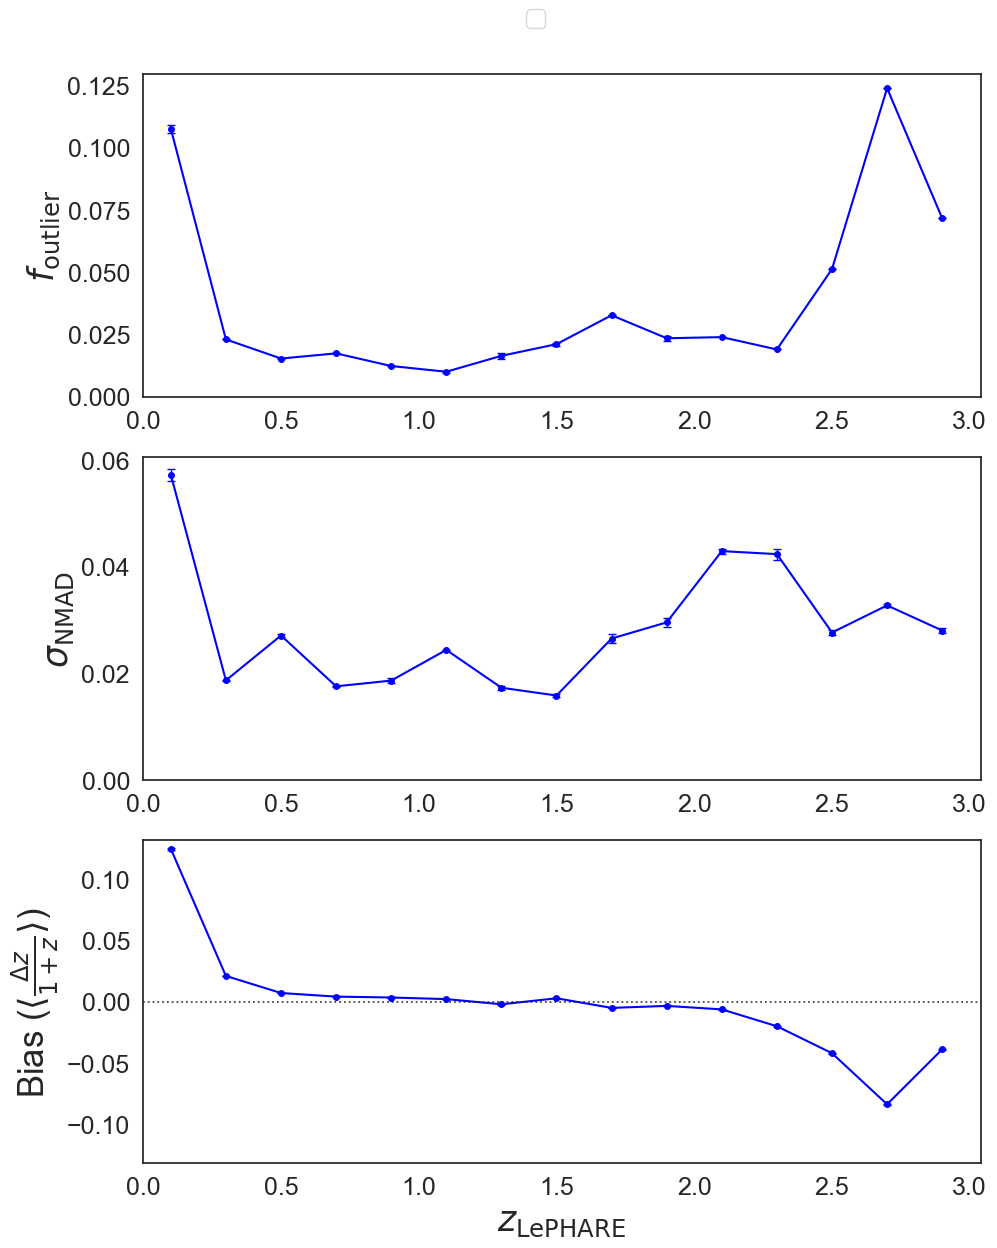

In [11]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(10,12))

    fout_ymax = 1.05*(np.max(k_binned_results['outliers_mean'])+np.max(k_binned_results['unc_k_outliers']))
    nmad_ymax = 1.05*(np.max(k_binned_results['nmads_mean'])+np.max(k_binned_results['unc_k_nmads']))
    bias_ymax = 1.05*(np.max(k_binned_results['biases_mean'])+np.max(k_binned_results['unc_k_biases']))
    bin_centers = k_binned_results['bin_centers']
    bin_min = 0.0

    # OUTLIERS
    #axs[0].plot(bin_centers, umap_outliers, c='blue', ls='--', label='UMAP (LePHARE-trained)')
    #axs[0].scatter(bin_centers, umap_outliers, c='blue', s=20)
    metric='outliers'
    axs[0].errorbar(bin_centers, k_binned_results[metric+'_mean'], yerr=k_binned_results['unc_k_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[0].plot(bin_centers, k_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_ylim(0,None)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    #axs[1].plot(bin_centers, umap_nmads, c='blue', ls='--')
    #axs[1].scatter(bin_centers, umap_nmads, c='blue', s=20)
    metric='nmads'
    axs[1].errorbar(bin_centers, k_binned_results[metric+'_mean'], yerr=k_binned_results['unc_k_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[1].plot(bin_centers, k_binned_results[metric+'_mean'], c='blue', ls='-')


    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_ylim(0,None)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    #axs[2].plot(bin_centers, umap_biases, c='blue', ls='--')
    #axs[2].scatter(bin_centers, umap_biases, c='blue', s=20)
    metric='biases'
    axs[2].errorbar(bin_centers, k_binned_results[metric+'_mean'], yerr=k_binned_results['unc_k_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[2].plot(bin_centers, k_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_ylim(-bias_ymax,bias_ymax)
    axs[2].set_xlim(bin_min,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### uncertainty due to n_neighbors optimization

The best value overall seems to be n_neighbors=80, with most nearby values also giving reasonable results. We created embeddings using +/-15% of the n_neighbors value, and holding the the random seed and k-value constant, we can quantify the uncertainty associated with choice of n_neighbors value. The +/-15% values are 68 and 92.

In [12]:
#data_nn = pd.read_parquet('som_umap_uncbudget_maps_260415.parquet')
data_nn = pd.read_parquet('umap_nn607081_250819.parquet')
spec_nn_maps = pd.merge(left=spec95[['ID', 'specz']], right=data_nn, left_on='ID', right_on='ID')
nn_splits = umapz2.data_split(photcat=data_nn, speccat=spec_nn_maps, valid_size=len(spec_nn_maps))
nn_valid = nn_splits['valid'].copy()

In [13]:
nn_hps = [60, 70, 81]

nn_b_sets = {str(nn_hp): [0] for nn_hp in nn_hps}
nn_b_results = {str(nn_hp): [0] for nn_hp in nn_hps}

nn_b_outliers_mean = []
nn_b_nmads_mean = []
nn_b_biases_mean = []

for nn_hp in nn_hps:
    nn_b_results[str(nn_hp)], nn_b_sets[str(nn_hp)] = umapz2.crossvalidate_binned(folds=5, data=nn_valid, nn=15, 
                                                        map='UMAPnn'+str(nn_hp), tv='lp_photoz')
    nn_b_outliers_mean.append(nn_b_results[str(nn_hp)]['outliers_mean'])
    nn_b_nmads_mean.append(nn_b_results[str(nn_hp)]['nmads_mean'])
    nn_b_biases_mean.append(nn_b_results[str(nn_hp)]['biases_mean'])

unc_nn_outliers = (np.asarray(nn_b_outliers_mean).max(axis=0) - np.asarray(nn_b_outliers_mean).min(axis=0))/2
unc_nn_nmads = (np.asarray(nn_b_nmads_mean).max(axis=0) - np.asarray(nn_b_nmads_mean).min(axis=0))/2
unc_nn_biases = (np.asarray(nn_b_biases_mean).max(axis=0) - np.asarray(nn_b_biases_mean).min(axis=0))/2

In [14]:
nn_binned_results = {
'bin_centers':nn_b_results['70']['bin_centers'],
'outliers_mean':nn_b_results['70']['outliers_mean'],
'nmads_mean':nn_b_results['70']['nmads_mean'],
'biases_mean':nn_b_results['70']['biases_mean'],
'unc_nn_outliers':unc_nn_outliers,
'unc_nn_nmads':unc_nn_nmads,
'unc_nn_biases':unc_nn_biases
}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


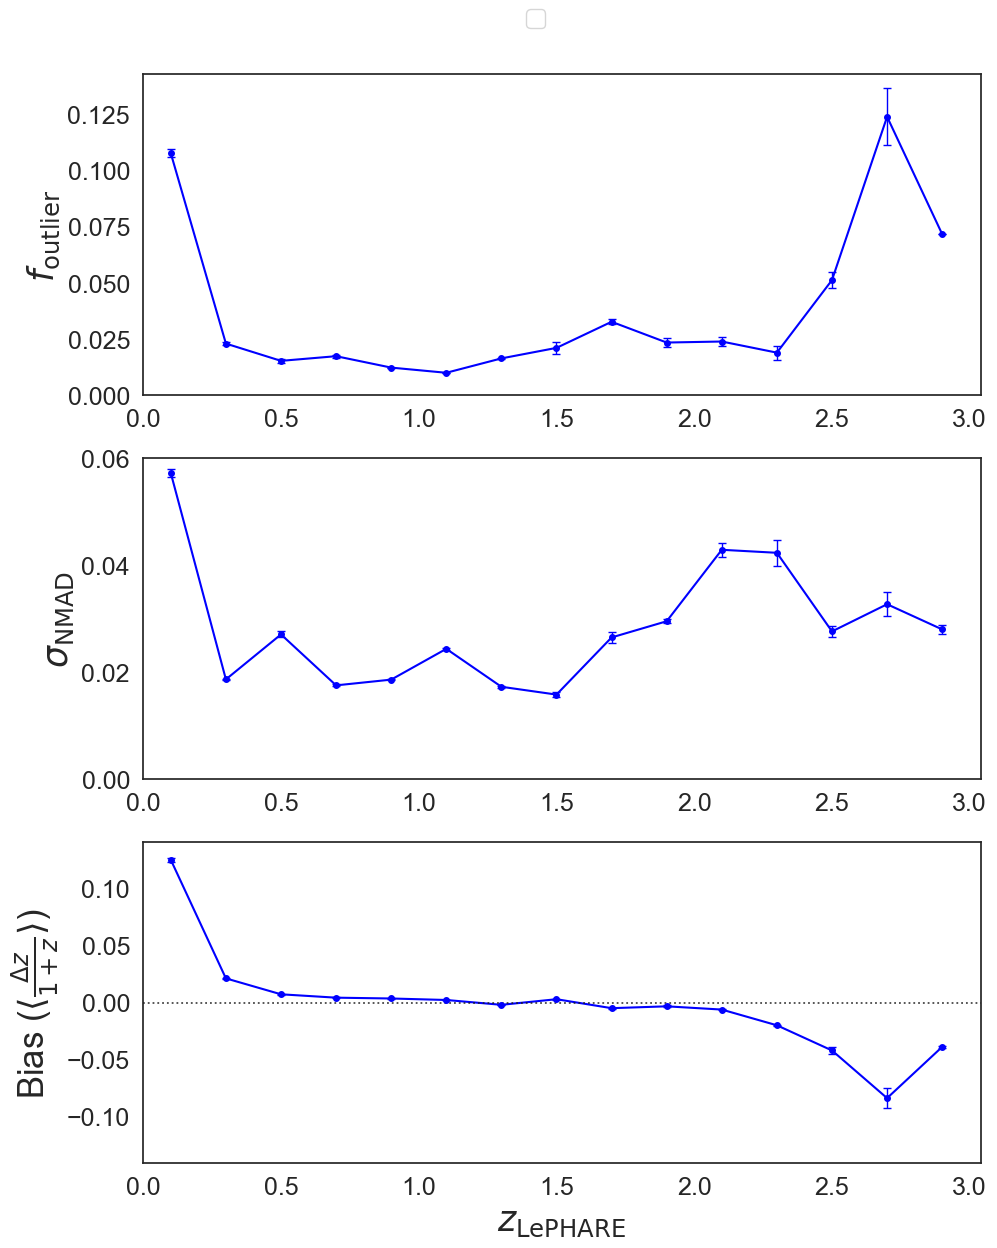

In [15]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(10,12))

    fout_ymax = 1.05*(np.max(nn_binned_results['outliers_mean'])+np.max(nn_binned_results['unc_nn_outliers']))
    nmad_ymax = 1.05*(np.max(nn_binned_results['nmads_mean'])+np.max(nn_binned_results['unc_nn_nmads']))
    bias_ymax = 1.05*(np.max(nn_binned_results['biases_mean'])+np.max(nn_binned_results['unc_nn_biases']))
    bin_centers = nn_binned_results['bin_centers']
    bin_min = 0.0

    # OUTLIERS
    #axs[0].plot(bin_centers, umap_outliers, c='blue', ls='--', label='UMAP (LePHARE-trained)')
    #axs[0].scatter(bin_centers, umap_outliers, c='blue', s=20)
    metric='outliers'
    axs[0].errorbar(bin_centers, nn_binned_results[metric+'_mean'], yerr=nn_binned_results['unc_nn_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[0].plot(bin_centers, nn_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_ylim(0,None)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    #axs[1].plot(bin_centers, umap_nmads, c='blue', ls='--')
    #axs[1].scatter(bin_centers, umap_nmads, c='blue', s=20)
    metric='nmads'
    axs[1].errorbar(bin_centers, nn_binned_results[metric+'_mean'], yerr=nn_binned_results['unc_nn_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[1].plot(bin_centers, nn_binned_results[metric+'_mean'], c='blue', ls='-')


    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_ylim(0,None)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    #axs[2].plot(bin_centers, umap_biases, c='blue', ls='--')
    #axs[2].scatter(bin_centers, umap_biases, c='blue', s=20)
    metric='biases'
    axs[2].errorbar(bin_centers, nn_binned_results[metric+'_mean'], yerr=nn_binned_results['unc_nn_'+metric], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[2].plot(bin_centers, nn_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_ylim(-bias_ymax,bias_ymax)
    axs[2].set_xlim(bin_min,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### uncertainty due to different random seeds

In [16]:
#rs_data = pd.read_parquet('photo_rs25_maps.parquet') # 'photo_rs25_maps.parquet' was made with n_neighbors=80
#rs_data = pd.read_parquet('umap_nn70_rs25_260519.parquet') # was made with min_dist=0.1 :/
rs_data = pd.read_parquet('umap_nn70_rs25_260523.parquet')

In [17]:
rs_spec = pd.merge(rs_data.copy()[rs_data['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
rs_test = rs_data.copy()[rs_data['ID'].isin(splits['test_spec']['ID'])]
rs_test_lp = rs_data.copy()[rs_data['ID'].isin(splits['test_lp']['ID'])]
rs_train_lp = rs_data.copy()[rs_data['ID'].isin(splits['train_lp']['ID'])]

The cell below both performs the interpolation in each random seed embedding, as well as calculating the global performance metrics in each case. 

In [18]:
n_embeddings=25
outliers_rs = []
nmads_rs = []
biases_rs = []

outliers_rs_lp = []
nmads_rs_lp = []
biases_rs_lp = []

# interpolate
for i in range(n_embeddings):
    rs_test['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=rs_spec, df2=rs_test, map='UMAPrs'+str(i), dim=3, nn=15, calc='median', z_true='specz').copy()['TEST_Z']
    outliers_rs.append(umapz2.f_outlier(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz'], missing=0, threshold=0.15))
    nmads_rs.append(umapz2.calc_nmad(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz']))
    biases_rs.append(umapz2.calc_bias(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz']))

    rs_test_lp['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=rs_train_lp, df2=rs_test_lp, map='UMAPrs'+str(i), dim=3, nn=15, calc='median', z_true='lp_photoz').copy()['TEST_Z']
    outliers_rs_lp.append(umapz2.f_outlier(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz'], missing=0, threshold=0.15))
    nmads_rs_lp.append(umapz2.calc_nmad(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz']))
    biases_rs_lp.append(umapz2.calc_bias(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz']))

The following cell calculates and packages the global performance metrics resulting from the random seed test. The averages of each performance metric, and their standard deviations, are recorded. Since this run was done with the "real"/"best" hyperparameter values and the real train/test sets, and doesn't "contaminate" our choices of any parameters or hyperparameters, the means of the performance metrics in each bin can be used as the UMAP final performance metrics for our results figures. 

This way, they will be the averaged results of using 25 different random seeds to generate the embeddings, and won't represent any anomalously good or bad results (although the tiny uncertainties associated with different random seeds indicate this wouldn't make a significant difference for UMAP).

In [19]:
# convert to arrays: shape = (n_realizations, n_bins)
outliers_rs = np.asarray(outliers_rs)
nmads_rs = np.asarray(nmads_rs)
biases_rs = np.asarray(biases_rs)

outliers_rs_lp = np.asarray(outliers_rs_lp)
nmads_rs_lp = np.asarray(nmads_rs_lp)
biases_rs_lp = np.asarray(biases_rs_lp)

rs_results = {
    "outliers_mean": outliers_rs.mean(axis=0),
    "outliers_std": outliers_rs.std(axis=0),

    "nmads_mean": nmads_rs.mean(axis=0),
    "nmads_std": nmads_rs.std(axis=0),

    "biases_mean": biases_rs.mean(axis=0),
    "biases_std": biases_rs.std(axis=0),

    "outliers_mean_lp": outliers_rs_lp.mean(axis=0),
    "outliers_std_lp": outliers_rs_lp.std(axis=0),

    "nmads_mean_lp": nmads_rs_lp.mean(axis=0),
    "nmads_std_lp": nmads_rs_lp.std(axis=0),

    "biases_mean_lp": biases_rs_lp.mean(axis=0),
    "biases_std_lp": biases_rs_lp.std(axis=0)
}

In [20]:
metrics = ['outliers', 'nmads', 'biases']
for metric in metrics:
    print(metric+' mean:', rs_results[metric+'_mean'])
    print(metric+' stdev:', rs_results[metric+'_std'])

outliers mean: 0.02463341843155586
outliers stdev: 0.00014158434444137643
nmads mean: 0.02504178983609868
nmads stdev: 4.455761919518235e-05
biases mean: 0.004671131067778234
biases stdev: 9.97263037965766e-05


In [21]:
testcats_rs = []
testcats_rs_lp = []
for i in range(1,n_embeddings): 
    testcat_i = rs_test.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]]
    testcat_i['TEST_Z'] = testcat_i['TEST_Zrs'+str(i)]
    testcats_rs.append(testcat_i.copy())

    testcat_i_lp = rs_test_lp.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]]
    testcat_i_lp['TEST_Z'] = testcat_i_lp['TEST_Zrs'+str(i)]
    testcats_rs_lp.append(testcat_i_lp.copy())

rs_binned_results = umapz2.binned_stats_ensemble(fullcats=testcats_rs, testcats=testcats_rs, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)
rs_binned_results_lp = umapz2.binned_stats_ensemble(fullcats=testcats_rs_lp, testcats=testcats_rs_lp, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


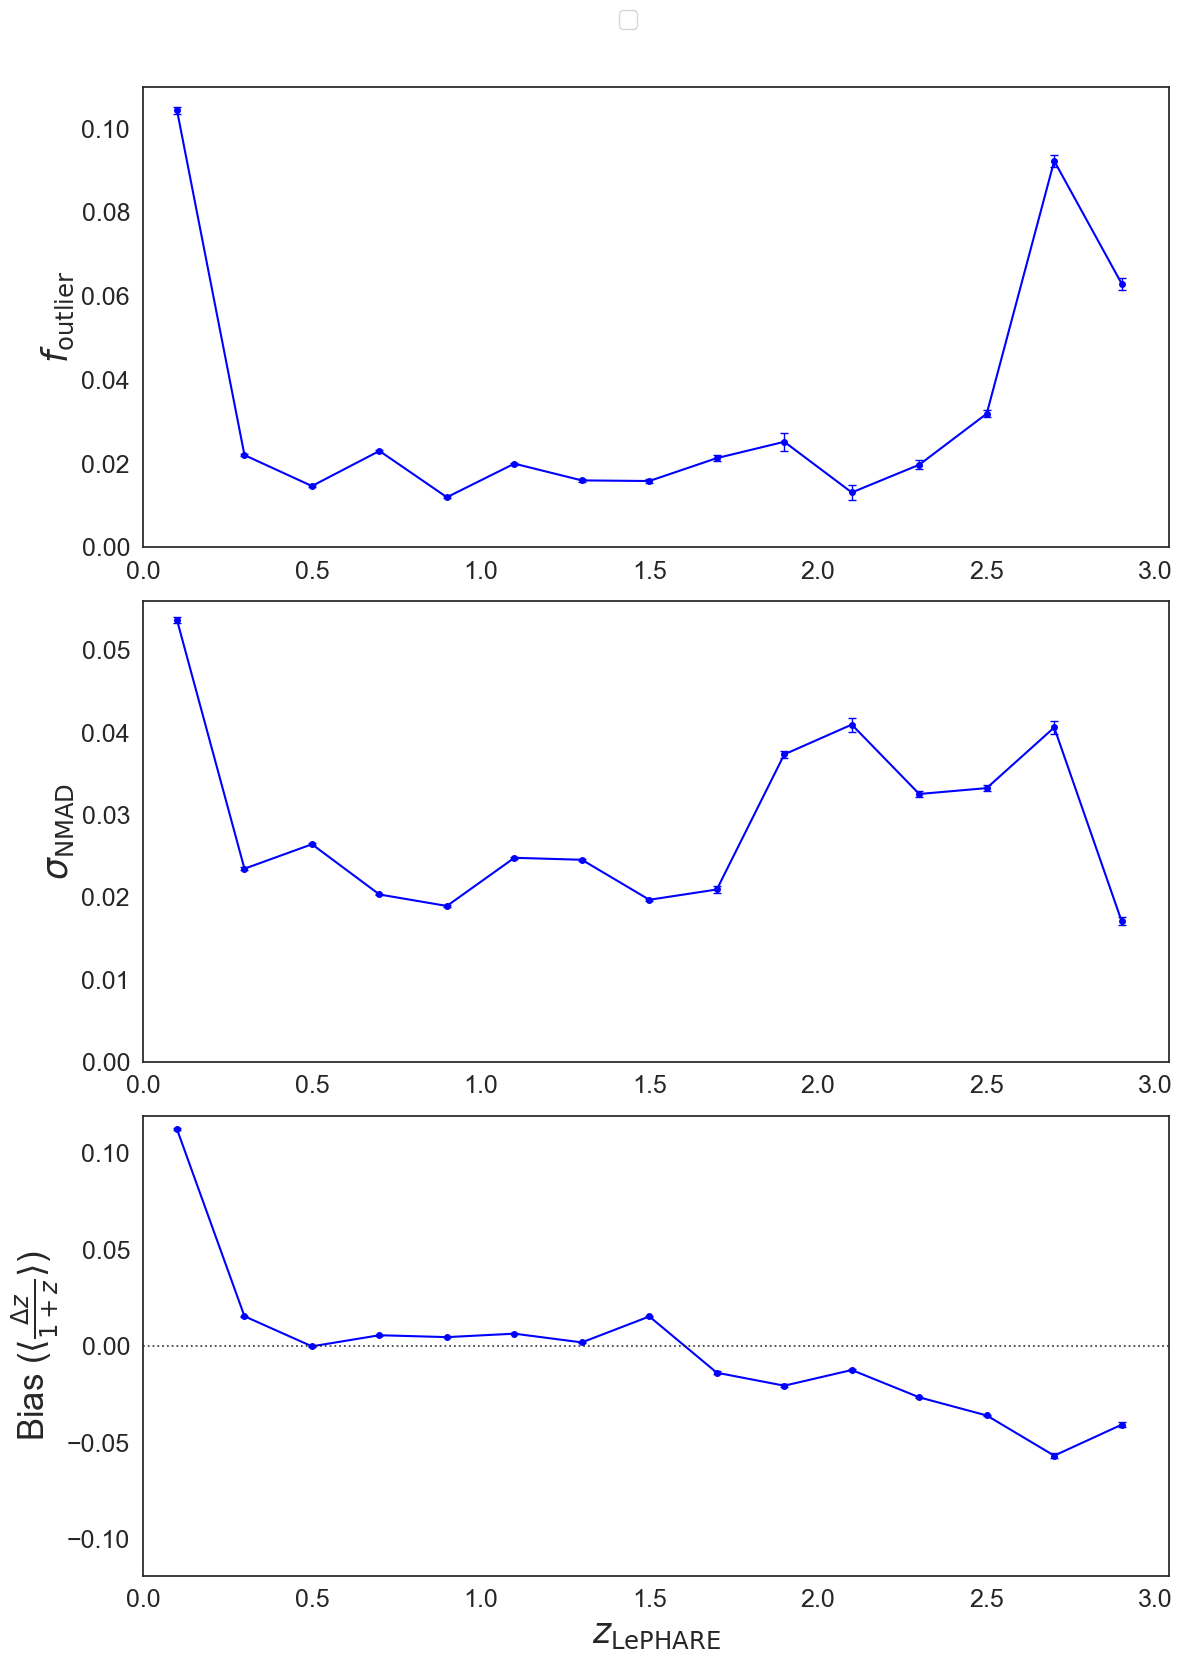

In [22]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(12,16))

    fout_ymax = 1.05*(np.max(rs_binned_results['outliers_mean'])+np.max(rs_binned_results['outliers_std']))
    nmad_ymax = 1.05*(np.max(rs_binned_results['nmads_mean'])+np.max(rs_binned_results['nmads_std']))
    bias_ymax = 1.05*(np.max(rs_binned_results['biases_mean'])+np.max(rs_binned_results['biases_std']))
    bin_centers = rs_binned_results['bin_centers']
    bin_min = 0.0

    # OUTLIERS
    #axs[0].plot(bin_centers, umap_outliers, c='blue', ls='--', label='UMAP (LePHARE-trained)')
    #axs[0].scatter(bin_centers, umap_outliers, c='blue', s=20)
    metric='outliers'
    axs[0].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=rs_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[0].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')


    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_ylim(0,None)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    #axs[1].plot(bin_centers, umap_nmads, c='blue', ls='--')
    #axs[1].scatter(bin_centers, umap_nmads, c='blue', s=20)
    metric='nmads'
    axs[1].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=rs_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[1].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_ylim(0,None)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    #axs[2].plot(bin_centers, umap_biases, c='blue', ls='--')
    #axs[2].scatter(bin_centers, umap_biases, c='blue', s=20)
    metric='biases'
    axs[2].errorbar(bin_centers, rs_binned_results[metric+'_mean'], yerr=rs_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[2].plot(bin_centers, rs_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_ylim(-bias_ymax,bias_ymax)
    axs[2].set_xlim(bin_min,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### uncertainty due to finite test set

To quantify the uncertainty due to the finite test set, we take 10-25 bootstrap samples of the test set (spec-z-trained case) and perform the main redshift-binned interpolation test with fixed k, n_neighbors, and random seed. The standard deviation of the performance metrics in each bin will be taken as the uncertainty due to finite test size.

Since the random seed test we just performed used fixed n_neighbors and fixed k, if we pick a particular seed from which to use the interpolated redshifts, we can use this sample for our bootstrap performance statistics calculations.

Let's go with 3.

In [23]:
rs_test[['TEST_Zrs3']]

,TEST_Zrs3
7,0.69921
39,0.47120
40,1.56543
46,1.08382
76,1.17910
...,...
746897,0.24874
746898,2.23730
746904,2.42186
746908,0.83100


In [24]:
n_boots=25
rs=3
outliers_boots = []
nmads_boots = []
stdevs_boots = []
biases_boots = []
testcats_boots = []
outliers_boots_lp = []
nmads_boots_lp = []
stdevs_boots_lp = []
biases_boots_lp = []
testcats_boots_lp = []

for i in range(1, n_boots+1):
    boot_i = rs_test.sample(n=len(rs_test), replace=True, random_state=i)
    testcats_boots.append(boot_i.copy())
    outliers_boots.append(umapz2.f_outlier(i_vals=boot_i['TEST_Zrs'+str(rs)], t_vals=boot_i['lp_photoz'], 
                                           missing=0, threshold=0.15))
    nmads_boots.append(umapz2.calc_nmad(i_vals=boot_i['TEST_Zrs'+str(rs)], t_vals=boot_i['lp_photoz']))
    stdevs_boots.append(umapz2.calc_stdev(i_vals=boot_i['TEST_Zrs'+str(rs)], t_vals=boot_i['lp_photoz']))
    biases_boots.append(umapz2.calc_bias(i_vals=boot_i['TEST_Zrs'+str(rs)], t_vals=boot_i['lp_photoz']))

    boot_i_lp = rs_test_lp.sample(n=len(rs_test_lp), replace=True, random_state=i)
    testcats_boots_lp.append(boot_i_lp.copy())
    outliers_boots_lp.append(umapz2.f_outlier(i_vals=boot_i_lp['TEST_Zrs'+str(rs)], t_vals=boot_i_lp['lp_photoz'], 
                                           missing=0, threshold=0.15))
    nmads_boots_lp.append(umapz2.calc_nmad(i_vals=boot_i_lp['TEST_Zrs'+str(rs)], t_vals=boot_i_lp['lp_photoz']))
    stdevs_boots_lp.append(umapz2.calc_stdev(i_vals=boot_i_lp['TEST_Zrs'+str(rs)], t_vals=boot_i_lp['lp_photoz']))
    biases_boots_lp.append(umapz2.calc_bias(i_vals=boot_i_lp['TEST_Zrs'+str(rs)], t_vals=boot_i_lp['lp_photoz']))

In [25]:
# convert to arrays: shape = (n_realizations, n_bins)
outliers_boots = np.asarray(outliers_boots)
nmads_boots = np.asarray(nmads_boots)
stdevs_boots = np.asarray(stdevs_boots)
biases_boots = np.asarray(biases_boots)

outliers_boots_lp = np.asarray(outliers_boots_lp)
nmads_boots_lp = np.asarray(nmads_boots_lp)
stdevs_boots_lp = np.asarray(stdevs_boots_lp)
biases_boots_lp = np.asarray(biases_boots_lp)

boots_results = {
    "outliers_mean": outliers_boots.mean(axis=0),
    "outliers_std": outliers_boots.std(axis=0),

    "nmads_mean": nmads_boots.mean(axis=0),
    "nmads_std": nmads_boots.std(axis=0),

    "stdevs_mean": stdevs_boots.mean(axis=0),
    "stdevs_std": stdevs_boots.std(axis=0),

    "biases_mean": biases_boots.mean(axis=0),
    "biases_std": biases_boots.std(axis=0),

    "outliers_mean_lp": outliers_boots_lp.mean(axis=0),
    "outliers_std_lp": outliers_boots_lp.std(axis=0),

    "nmads_mean_lp": nmads_boots_lp.mean(axis=0),
    "nmads_std_lp": nmads_boots_lp.std(axis=0),

    "stdevs_mean_lp": stdevs_boots_lp.mean(axis=0),
    "stdevs_std_lp": stdevs_boots_lp.std(axis=0),

    "biases_mean_lp": biases_boots_lp.mean(axis=0),
    "biases_std_lp": biases_boots_lp.std(axis=0)
}

In [26]:
metrics = ['outliers', 'nmads', 'stdevs', 'biases']
for metric in metrics:
    print(metric+' mean:', np.round(boots_results[metric+'_mean'], 6))
    print(metric+' stdev:', np.round(boots_results[metric+'_std'], 6))

outliers mean: 0.024778
outliers stdev: 0.000606
nmads mean: 0.02499
nmads stdev: 0.000106
stdevs mean: 0.134579
stdevs stdev: 0.002743
biases mean: 0.004914
biases stdev: 0.000341


In [27]:
boots_binned_results = umapz2.binned_stats_ensemble(fullcats=testcats_boots, testcats=testcats_boots, iv='TEST_Zrs'+str(rs), tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)

boots_binned_results_lp = umapz2.binned_stats_ensemble(fullcats=testcats_boots_lp, testcats=testcats_boots_lp, iv='TEST_Zrs'+str(rs), tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


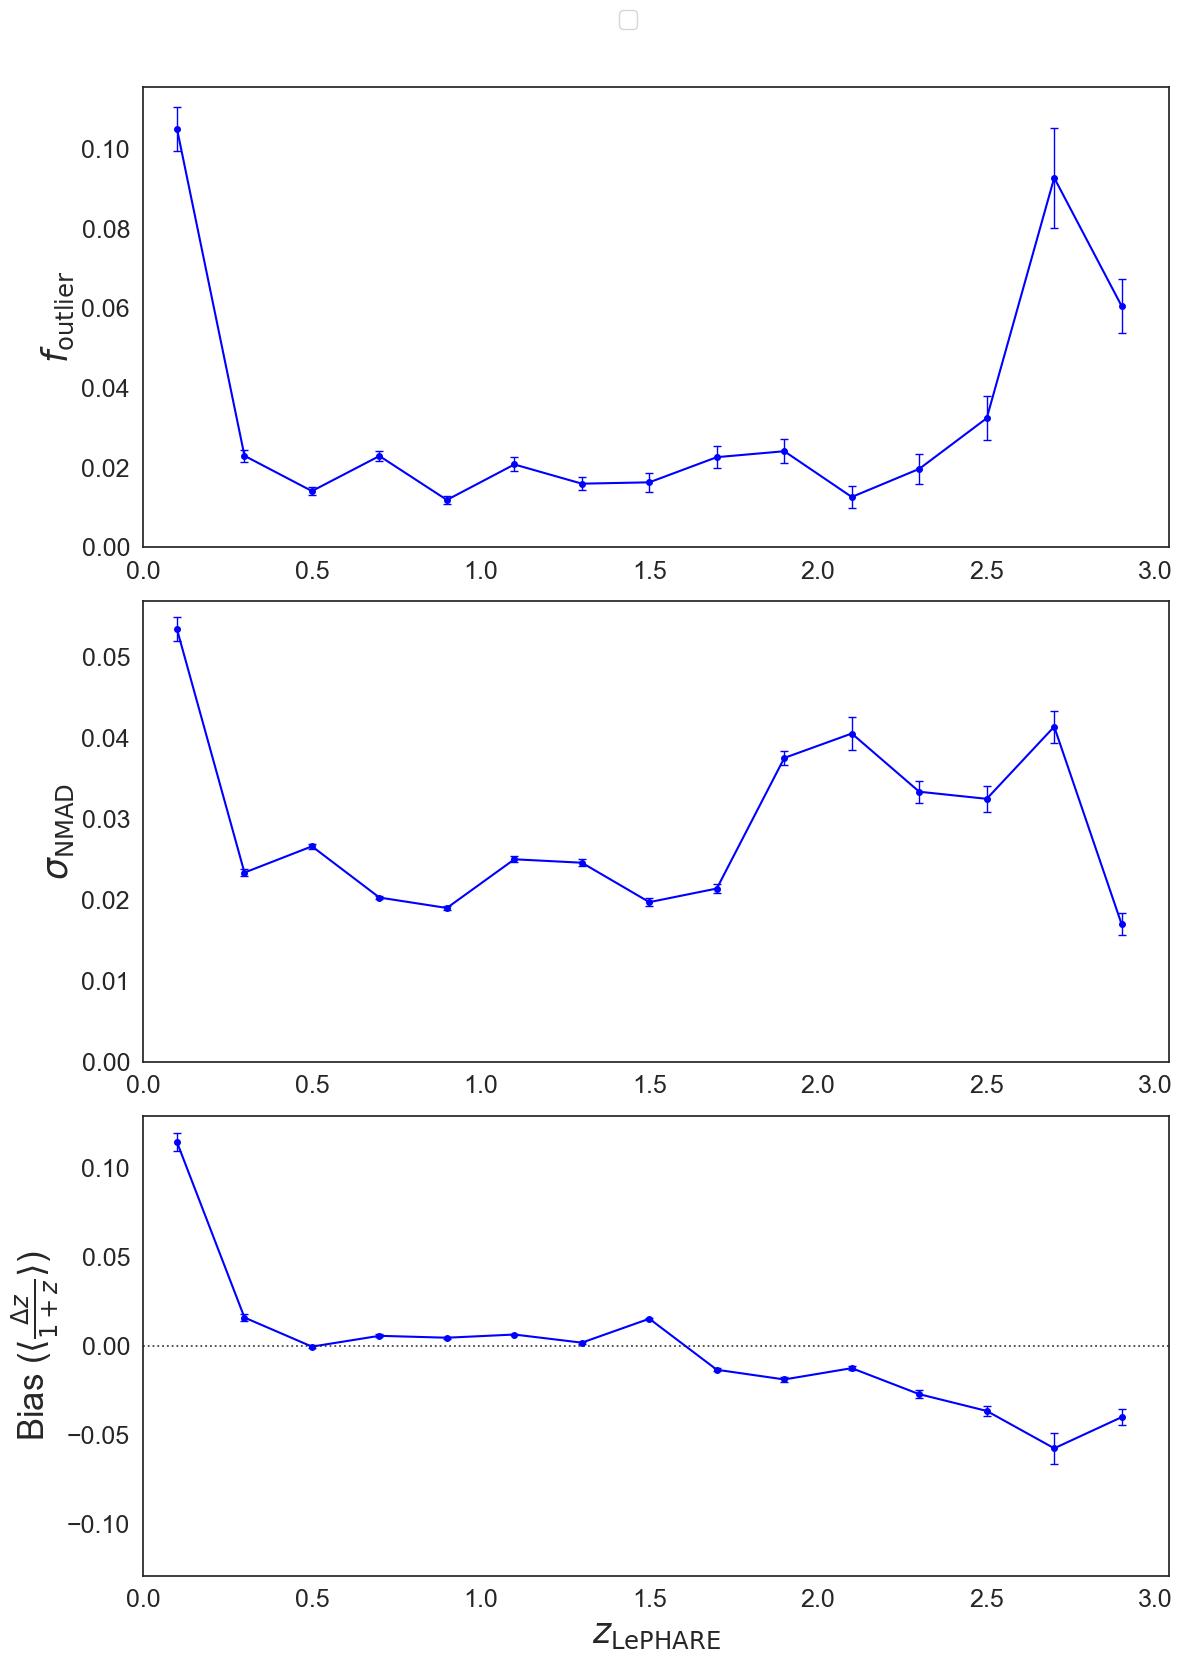

In [28]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(12,16))

    fout_ymax = 1.05*(np.max(boots_binned_results['outliers_mean'])+np.max(boots_binned_results['outliers_std']))
    nmad_ymax = 1.05*(np.max(boots_binned_results['nmads_mean'])+np.max(boots_binned_results['nmads_std']))
    bias_ymax = 1.05*(np.max(boots_binned_results['biases_mean'])+np.max(boots_binned_results['biases_std']))
    bin_centers = boots_binned_results['bin_centers']
    bin_min = 0.0

    # OUTLIERS
    #axs[0].plot(bin_centers, umap_outliers, c='blue', ls='--', label='UMAP (LePHARE-trained)')
    #axs[0].scatter(bin_centers, umap_outliers, c='blue', s=20)
    metric='outliers'
    axs[0].errorbar(bin_centers, boots_binned_results[metric+'_mean'], yerr=boots_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[0].plot(bin_centers, boots_binned_results[metric+'_mean'], c='blue', ls='-')


    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_ylim(0,None)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)
    # NMADS
    #axs[1].plot(bin_centers, umap_nmads, c='blue', ls='--')
    #axs[1].scatter(bin_centers, umap_nmads, c='blue', s=20)
    metric='nmads'
    axs[1].errorbar(bin_centers, boots_binned_results[metric+'_mean'], yerr=boots_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[1].plot(bin_centers, boots_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_ylim(0,None)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)
    # BIASES
    #axs[2].plot(bin_centers, umap_biases, c='blue', ls='--')
    #axs[2].scatter(bin_centers, umap_biases, c='blue', s=20)
    metric='biases'
    axs[2].errorbar(bin_centers, boots_binned_results[metric+'_mean'], yerr=boots_binned_results[metric+'_std'], fmt='o', capsize=3,
                    lw=1, ms=4, c='blue')
    axs[2].plot(bin_centers, boots_binned_results[metric+'_mean'], c='blue', ls='-')

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_ylim(-bias_ymax,bias_ymax)
    axs[2].set_xlim(bin_min,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('SOM vs UMAP: Statistics by Redshift', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### spec-z-trained sandplot

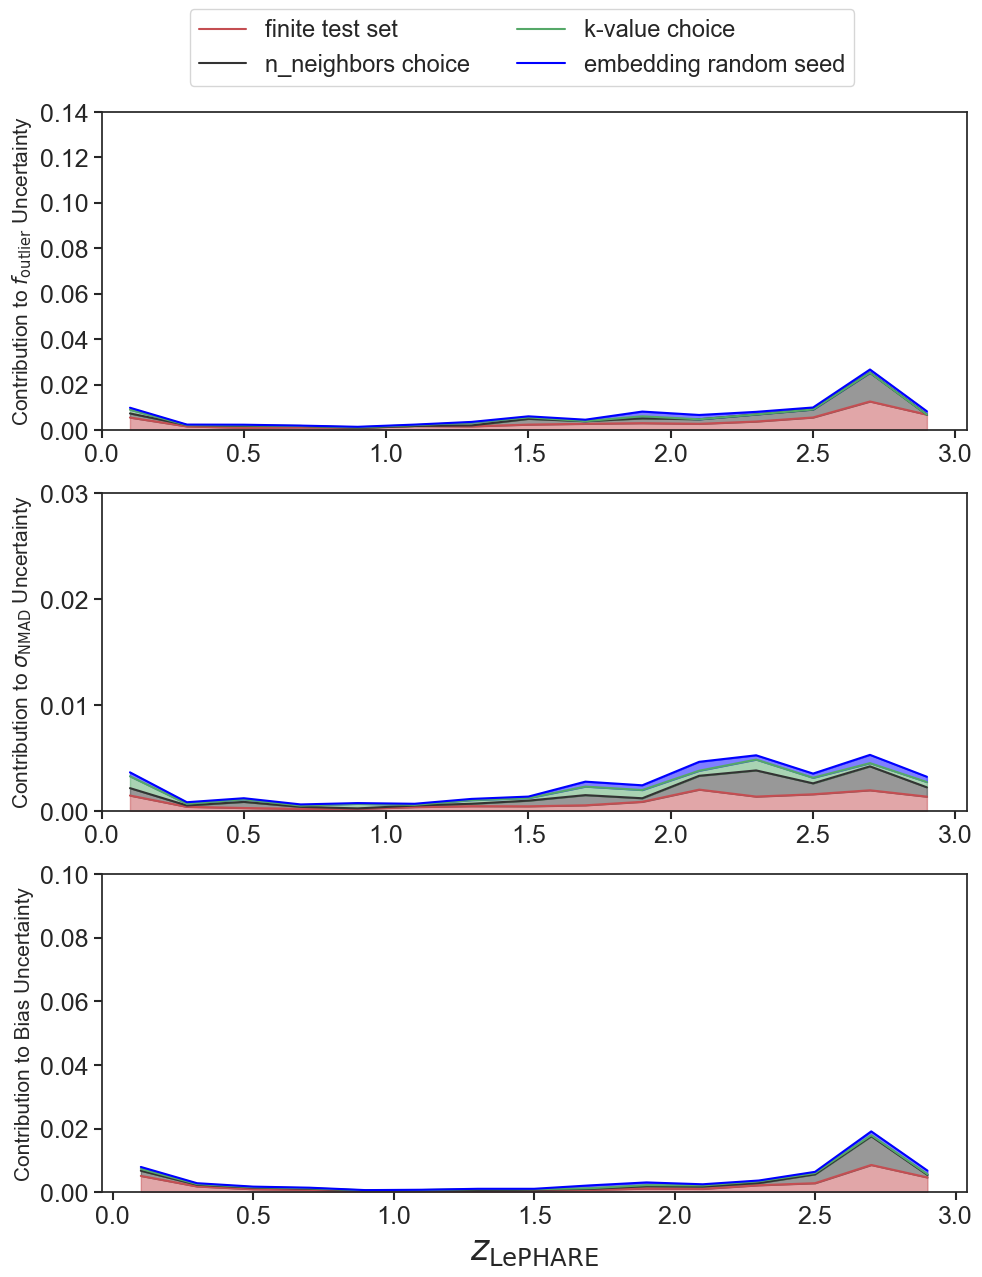

In [29]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(10,12))
    c1, c2, c3, c4 = 'r', '0.2', 'g', 'blue'
    l4 = 'embedding random seed'
    l3 = 'k-value choice'
    l2 = 'n_neighbors choice'
    l1 = 'finite test set'
    alpha=0.5

    #ticks
    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=18, length=6, width=1.5, 
                        bottom=True,top=False,left=True, right=False,
                        direction='out')
        #ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    axs[0].yaxis.set_major_locator(MultipleLocator(0.02))
    axs[1].yaxis.set_major_locator(MultipleLocator(0.01))
    axs[2].yaxis.set_major_locator(MultipleLocator(0.02))
    
    # OUTLIERS
    metric='outliers'
    unc1, unc2, unc3, unc4 = boots_binned_results[metric+'_std'], nn_binned_results['unc_nn_'+metric], k_binned_results['unc_k_'+metric], rs_binned_results[metric+"_std"]
    axs[0].plot(bin_centers, unc1, c=c1, ls='-', label=l1)
    axs[0].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[0].plot(bin_centers, unc2+unc1, c=c2, ls='-', label=l2)
    axs[0].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[0].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-', label=l3)
    axs[0].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[0].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-', label=l4)
    axs[0].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel('Contribution to '+r'$f_\mathrm{outlier}$'+' Uncertainty', fontsize=15)
    axs[0].set_ylim(0, 0.14)
    # NMADS
    metric='nmads'
    unc1, unc2, unc3, unc4 = boots_binned_results[metric+'_std'], nn_binned_results['unc_nn_'+metric], k_binned_results['unc_k_'+metric], rs_binned_results[metric+"_std"]
    axs[1].plot(bin_centers, unc1, c=c1, ls='-')
    axs[1].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[1].plot(bin_centers, unc2+unc1, c=c2, ls='-')
    axs[1].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[1].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-')
    axs[1].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[1].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-')
    axs[1].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel('Contribution to '+r'$\sigma_\mathrm{NMAD}$'+' Uncertainty', fontsize=15)
    axs[1].set_ylim(0, 0.03)
    # BIASES
    metric='biases'
    unc1, unc2, unc3, unc4 = boots_binned_results[metric+'_std'], nn_binned_results['unc_nn_'+metric], k_binned_results['unc_k_'+metric], rs_binned_results[metric+"_std"]
    axs[2].plot(bin_centers, unc1, c=c1, ls='-')
    axs[2].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[2].plot(bin_centers, unc2+unc1, c=c2, ls='-')
    axs[2].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[2].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-')
    axs[2].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[2].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-')
    axs[2].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Contribution to Bias Uncertainty', fontsize=15)
    axs[2].set_ylim(0, 0.1)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('Uncertainties Related to UMAP Embedding and Optimization', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### LePHARE-trained sandplot

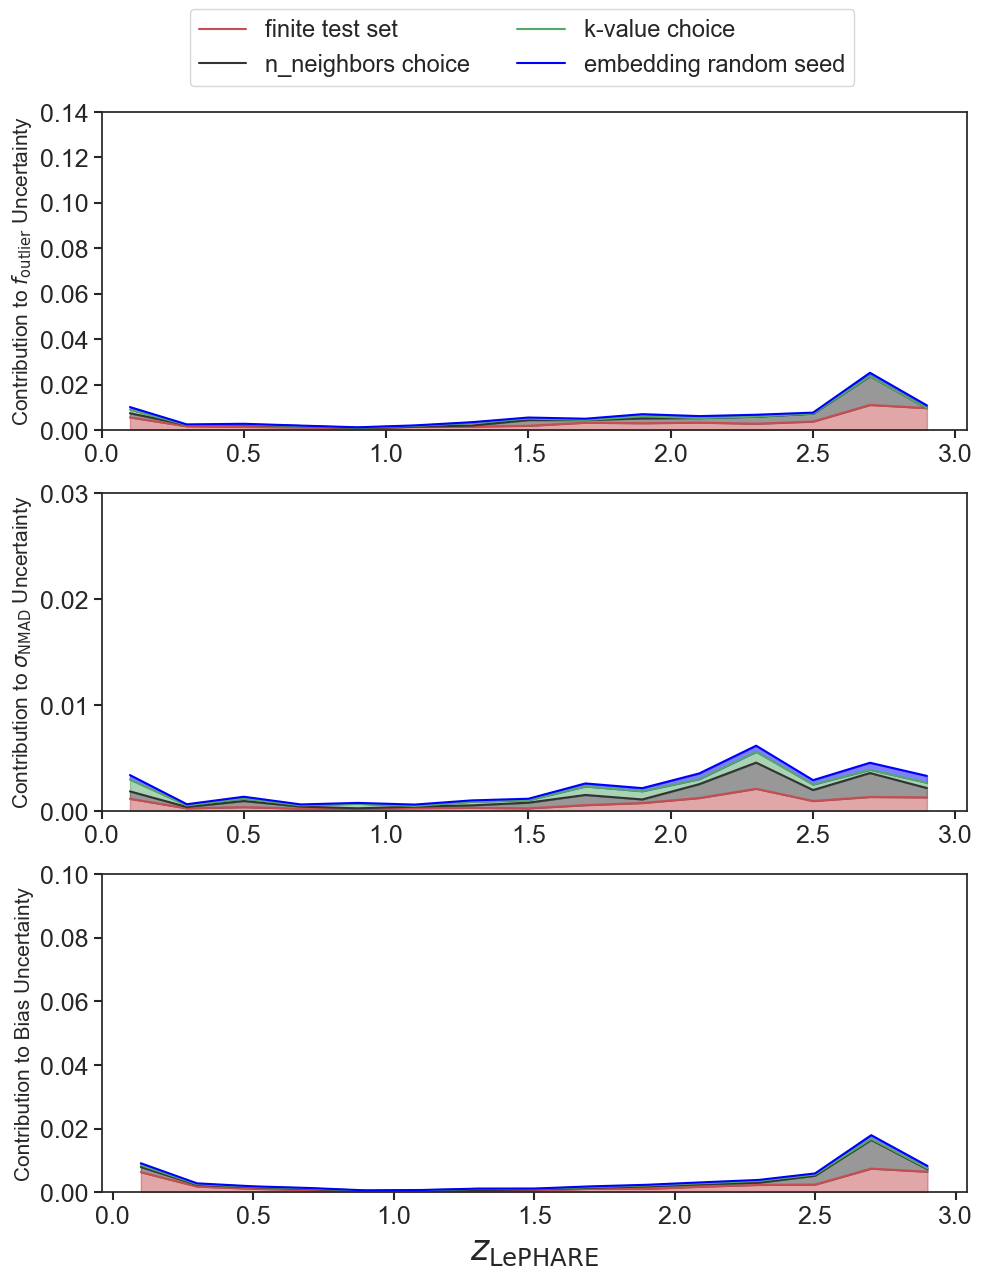

In [30]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(10,12))
    c1, c2, c3, c4 = 'r', '0.2', 'g', 'blue'
    l4 = 'embedding random seed'
    l3 = 'k-value choice'
    l2 = 'n_neighbors choice'
    l1 = 'finite test set'
    alpha=0.5

    #ticks
    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=18, length=6, width=1.5, 
                        bottom=True,top=False,left=True, right=False,
                        direction='out')
        #ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    axs[0].yaxis.set_major_locator(MultipleLocator(0.02))
    axs[1].yaxis.set_major_locator(MultipleLocator(0.01))
    axs[2].yaxis.set_major_locator(MultipleLocator(0.02))

    # OUTLIERS
    metric='outliers'
    unc1, unc2, unc3, unc4 = boots_binned_results_lp[metric+'_std'], nn_binned_results['unc_nn_'+metric], k_binned_results['unc_k_'+metric], rs_binned_results_lp[metric+"_std"]
    axs[0].plot(bin_centers, unc1, c=c1, ls='-', label=l1)
    axs[0].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[0].plot(bin_centers, unc2+unc1, c=c2, ls='-', label=l2)
    axs[0].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[0].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-', label=l3)
    axs[0].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[0].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-', label=l4)
    axs[0].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[0].set_xlim(bin_min,None)
    axs[0].set_ylabel('Contribution to '+r'$f_\mathrm{outlier}$'+' Uncertainty', fontsize=15)
    axs[0].set_ylim(0, 0.14)
    # NMADS
    metric='nmads'
    unc1, unc2, unc3, unc4 = boots_binned_results_lp[metric+'_std'], nn_binned_results['unc_nn_'+metric], k_binned_results['unc_k_'+metric], rs_binned_results_lp[metric+"_std"]
    axs[1].plot(bin_centers, unc1, c=c1, ls='-')
    axs[1].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[1].plot(bin_centers, unc2+unc1, c=c2, ls='-')
    axs[1].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[1].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-')
    axs[1].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[1].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-')
    axs[1].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[1].set_xlim(bin_min,None)
    axs[1].set_ylabel('Contribution to '+r'$\sigma_\mathrm{NMAD}$'+' Uncertainty', fontsize=15)
    axs[1].set_ylim(0, 0.03)
    # BIASES
    metric='biases'
    unc1, unc2, unc3, unc4 = boots_binned_results_lp[metric+'_std'], nn_binned_results['unc_nn_'+metric], k_binned_results['unc_k_'+metric], rs_binned_results_lp[metric+"_std"]
    axs[2].plot(bin_centers, unc1, c=c1, ls='-')
    axs[2].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
    axs[2].plot(bin_centers, unc2+unc1, c=c2, ls='-')
    axs[2].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
    axs[2].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-')
    axs[2].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
    axs[2].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-')
    axs[2].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
    axs[2].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    axs[2].set_ylabel('Contribution to Bias Uncertainty', fontsize=15)
    axs[2].set_ylim(0, 0.1)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=2, borderaxespad=0., fontsize=17)
    fig.tight_layout()
    #fig.suptitle('Uncertainties Related to UMAP Embedding and Optimization', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### Calculate total uncertainties (added in quadrature) and write out the results to use the error bars in performance figures.

In [31]:
# LePHARE-trained case
metric='outliers'
unc1_lp, unc2_lp, unc3_lp, unc4_lp = [boots_binned_results_lp[metric+'_std'], nn_binned_results['unc_nn_'+metric], 
    rs_binned_results_lp[metric+"_std"], k_binned_results['unc_k_'+metric]]
umap_outlier_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2 + unc3_lp**2 + unc4_lp**2)
metric='nmads'
unc1_lp, unc2_lp, unc3_lp, unc4_lp = [boots_binned_results_lp[metric+'_std'], nn_binned_results['unc_nn_'+metric], 
    rs_binned_results_lp[metric+"_std"], k_binned_results['unc_k_'+metric]]
umap_nmad_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2 + unc3_lp**2 + unc4_lp**2)
metric='biases'
unc1_lp, unc2_lp, unc3_lp, unc4_lp = [boots_binned_results_lp[metric+'_std'], nn_binned_results['unc_nn_'+metric], 
    rs_binned_results_lp[metric+"_std"], k_binned_results['unc_k_'+metric]]
umap_bias_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2 + unc3_lp**2 + unc4_lp**2)

# spec-z-trained case
metric='outliers'
unc1, unc2, unc3, unc4 = [boots_binned_results[metric+'_std'], nn_binned_results['unc_nn_'+metric], 
    rs_binned_results[metric+"_std"], k_binned_results['unc_k_'+metric]]
umap_outlier_uncs = np.sqrt(unc1**2 + unc2**2 + unc3**2 + unc4**2)
metric='nmads'
unc1, unc2, unc3, unc4 = [boots_binned_results[metric+'_std'], nn_binned_results['unc_nn_'+metric], 
    rs_binned_results[metric+"_std"], k_binned_results['unc_k_'+metric]]
umap_nmad_uncs = np.sqrt(unc1**2 + unc2**2 + unc3**2 + unc4**2)
metric='biases'
unc1, unc2, unc3, unc4 = [boots_binned_results[metric+'_std'], nn_binned_results['unc_nn_'+metric], 
    rs_binned_results[metric+"_std"], k_binned_results['unc_k_'+metric]]
umap_bias_uncs = np.sqrt(unc1**2 + unc2**2 + unc3**2 + unc4**2)

In [32]:
rs_binned_results['bin_centers']

array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3, 2.5,
       2.7, 2.9])

In [33]:
umap_binned = {
'specz_trained':{
    'f_outlier':{
        'mean':rs_binned_results['outliers_mean'],
        'unc':umap_outlier_uncs,
        'unc_k':k_binned_results['unc_k_outliers'],
        'unc_nn':nn_binned_results['unc_nn_outliers'],
        'unc_rs':rs_binned_results['outliers_std'],
        'unc_boots':boots_binned_results['outliers_std']
    },
    'nmad':{
        'mean':rs_binned_results['nmads_mean'],
        'unc':umap_nmad_uncs,
        'unc_k':k_binned_results['unc_k_nmads'],
        'unc_nn':nn_binned_results['unc_nn_nmads'],
        'unc_rs':rs_binned_results['nmads_std'],
        'unc_boots':boots_binned_results['nmads_std']
    },
    'bias':{
        'mean':rs_binned_results['biases_mean'],
        'unc':umap_bias_uncs,
        'unc_k':k_binned_results['unc_k_biases'],
        'unc_nn':nn_binned_results['unc_nn_biases'],
        'unc_rs':rs_binned_results['biases_std'],
        'unc_boots':boots_binned_results['biases_std']
    },
    'bin_centers':rs_binned_results['bin_centers']

},
'LePHARE_trained':{
    'f_outlier':{
        'mean':rs_binned_results_lp['outliers_mean'],
        'unc':umap_outlier_uncs_lp,
        'unc_k':k_binned_results['unc_k_outliers'],
        'unc_nn':nn_binned_results['unc_nn_outliers'],
        'unc_rs':rs_binned_results_lp['outliers_std'],
        'unc_boots':boots_binned_results_lp['outliers_std']
    },
    'nmad':{
        'mean':rs_binned_results_lp['nmads_mean'],
        'unc':umap_nmad_uncs_lp,
        'unc_k':k_binned_results['unc_k_nmads'],
        'unc_nn':nn_binned_results['unc_nn_nmads'],
        'unc_rs':rs_binned_results_lp['nmads_std'],
        'unc_boots':boots_binned_results_lp['nmads_std']
    },
    'bias':{
        'mean':rs_binned_results_lp['biases_mean'],
        'unc':umap_bias_uncs_lp,
        'unc_k':k_binned_results['unc_k_biases'],
        'unc_nn':nn_binned_results['unc_nn_biases'],
        'unc_rs':rs_binned_results_lp['biases_std'],
        'unc_boots':boots_binned_results_lp['biases_std']
    },
    'bin_centers':rs_binned_results_lp['bin_centers']

}
}

In [34]:
umap_binned['specz_trained']['bin_centers']

array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3, 2.5,
       2.7, 2.9])

In [35]:
#with open("umap_binned_260523.pkl", "wb") as f:
#    pickle.dump(umap_binned, f)

In [36]:
umap_errs = {'outliers':umap_outlier_uncs, 'nmads':umap_nmad_uncs, 'biases':umap_bias_uncs,
            'outliers_lp':umap_outlier_uncs_lp, 'nmads_lp':umap_nmad_uncs_lp, 'biases_lp':umap_bias_uncs_lp}

In [37]:
#with open("umap_errs_260523.pkl", "wb") as f: #comment out when not ready to use, for safety against overwriting :)
#    pickle.dump(umap_errs, f)

### Global Performance Metric Uncertainties

This section will compute the uncertainties on the full-sample performance statistics. The same approach will be used, taking the range of means divided by 2 for the uncertainties associated with our embedding/interpolator choices (n_neighbors, k), using 5-fold crossvalidation tests on the validation sample, and taking the standard deviation of the performance metrics obtained over 25 trials for the uncertainties associated with embedding random seed (25 seeds, spec-z train/test sets) and the finite test set (25 bootstraps of the (spec-z) test sample for one random seed run).

In [38]:
# valid contains the cell coordinates for the validation dataset for various embedding choice combinations, 
# all using the same random seed (42)
# this data is used to calculate the +/-15% uncertainties associated with choice of these
# parameters
valid

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,UMAPnn55-1,UMAPnn55-2,UMAPnn55-3,UMAPnn60-1,UMAPnn60-2,UMAPnn60-3,UMAPnn65-1,UMAPnn65-2,UMAPnn65-3,UMAPnn70-1,UMAPnn70-2,UMAPnn70-3,UMAPnn75-1,UMAPnn75-2,UMAPnn75-3,UMAPnn80-1,UMAPnn80-2,UMAPnn80-3,UMAPnn85-1,UMAPnn85-2,UMAPnn85-3
682744,888967,149.936450,2.785401,0,0.482169,0.008109,0.021217,0.556797,0.004353,0.008433,0.649724,0.005866,0.009340,0.815287,0.006075,0.008074,1.022175,0.009601,0.010115,1.516981,0.023160,0.015645,2.479349,0.054714,0.023929,3.181551,0.075771,0.027204,3.775385,0.057224,0.016556,5.577980,0.014766,0.003503,6.055261,0.017200,0.003780,1.5429,0,NaN,27,0.99,5,1.139000e+09,0.2,0,-19.84784,-21.53190,-22.12276,10.02579,9.89337,10.08403,10.03590,1.14004,-8.917,24.692001,24.535758,24.368177,24.121724,23.876187,23.447549,22.914156,22.643403,22.457597,22.033808,21.944668,0.156243,0.167580,0.246453,0.245537,0.428638,0.533394,0.270753,1.439148,3.688958,9.313959,1.442810,3.775632,9.351755,1.439867,3.747785,9.490368,1.454326,3.675086,9.452222,1.458698,3.668823,9.518856,1.452414,3.705678,9.563761,1.508997,3.737282,9.673626
705718,915989,150.389923,1.791782,0,0.300923,0.003346,0.013912,0.391560,0.003238,0.008863,0.729946,0.004244,0.005987,0.857738,0.004264,0.005368,0.908493,0.006994,0.008269,1.053736,0.015095,0.014646,1.133205,0.028540,0.027268,1.063807,0.038095,0.040864,1.151679,0.027239,0.025818,0.553292,0.012940,0.030942,0.312715,0.016622,0.070726,0.4445,0,NaN,30,0.00,1,3.210000e+08,0.0,0,-16.35030,-17.63879,-17.70557,8.08427,8.02849,8.19774,8.06536,-1.17000,-9.212,25.203863,24.918003,24.241773,24.066614,24.004195,23.843171,23.764228,23.832843,23.746671,24.542615,25.162128,0.285860,0.676230,0.175160,0.062418,0.161025,0.078942,-0.068615,0.233685,6.196652,-1.511555,0.397215,6.107618,-1.416063,0.380382,6.067251,-1.275412,0.509571,6.019083,-1.241365,0.494606,6.045729,-1.135778,0.544669,5.969252,-1.142448,0.631645,6.027142,-0.977793
132564,175014,150.121155,1.644934,0,0.281661,0.003567,0.015858,0.294709,0.003148,0.011457,0.385362,0.004180,0.011174,0.606247,0.004185,0.007456,0.866615,0.006661,0.008258,0.800703,0.015264,0.019495,0.987316,0.013438,0.014739,0.996477,0.017941,0.020548,0.986751,0.026845,0.029699,0.839995,0.013123,0.020670,0.550881,0.013868,0.033498,0.8564,0,NaN,29,0.00,7,1.015000e+09,0.1,1,-17.75778,-18.94959,-19.07940,8.71424,8.66864,8.75055,8.73949,-0.09519,-8.830,25.275684,25.226517,24.935328,24.443377,24.055434,24.141322,23.913860,23.903831,23.914481,24.089309,24.547356,0.049166,0.291189,0.491951,0.387943,-0.085888,0.227462,0.010028,-1.610478,1.378527,0.144451,-1.564668,1.292793,0.288109,-1.482627,1.274498,0.466413,-1.474319,1.242964,0.423220,-1.344020,1.247625,0.628222,-1.409336,1.195046,0.592069,-1.297494,1.307995,0.704876
38676,53915,150.365002,2.127347,0,0.467036,0.006094,0.016220,0.526304,0.004793,0.009714,0.840886,0.006087,0.007426,1.706182,0.006378,0.004026,2.390468,0.010503,0.004710,2.376359,0.021343,0.009167,3.818460,0.042345,0.011993,4.366636,0.056518,0.014759,5.914739,0.041212,0.007602,7.887154,0.016861,0.002828,6.016602,0.020844,0.004609,0.8240,0,NaN,29,0.74,3,5.709000e+08,0.3,0,-18.17301,-20.26624,-20.98757,9.55956,9.51840,9.59472,9.53026,0.81388,-8.720,24.726624,24.596909,2

In [39]:
# rs_data contains the cell coordinates for the full sample in 25 different random seed runs using the "best"
# embedding choices [size, sigma, learning_rate]
# this is used to calculate the uncertainties associated with the embedding random seed and with
# the finite test set size
rs_data

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,UMAPrs0-1,UMAPrs0-2,UMAPrs0-3,UMAPrs1-1,UMAPrs1-2,UMAPrs1-3,UMAPrs2-1,UMAPrs2-2,UMAPrs2-3,UMAPrs3-1,UMAPrs3-2,UMAPrs3-3,UMAPrs4-1,UMAPrs4-2,UMAPrs4-3,UMAPrs5-1,UMAPrs5-2,UMAPrs5-3,UMAPrs6-1,UMAPrs6-2,UMAPrs6-3,UMAPrs7-1,UMAPrs7-2,UMAPrs7-3,UMAPrs8-1,UMAPrs8-2,UMAPrs8-3,UMAPrs9-1,UMAPrs9-2,UMAPrs9-3,UMAPrs10-1,UMAPrs10-2,UMAPrs10-3,UMAPrs11-1,UMAPrs11-2,UMAPrs11-3,UMAPrs12-1,UMAPrs12-2,UMAPrs12-3,UMAPrs13-1,UMAPrs13-2,UMAPrs13-3,UMAPrs14-1,UMAPrs14-2,UMAPrs14-3,UMAPrs15-1,UMAPrs15-2,UMAPrs15-3,UMAPrs16-1,UMAPrs16-2,UMAPrs16-3,UMAPrs17-1,UMAPrs17-2,UMAPrs17-3,UMAPrs18-1,UMAPrs18-2,UMAPrs18-3,UMAPrs19-1,UMAPrs19-2,UMAPrs19-3,UMAPrs20-1,UMAPrs20-2,UMAPrs20-3,UMAPrs21-1,UMAPrs21-2,UMAPrs21-3,UMAPrs22-1,UMAPrs22-2,UMAPrs22-3,UMAPrs23-1,UMAPrs23-2,UMAPrs23-3,UMAPrs24-1,UMAPrs24-2,UMAPrs24-3
7,12,150.476809,2.331511,0,0.432424,0.006043,0.017385,0.367684,0.004799,0.013929,0.539085,0.006673,0.012705,0.913139,0.006940,0.008187,0.995689,0.010382,0.011179,1.010389,0.021430,0.021652,1.176385,0.018240,0.016771,1.238664,0.023098,0.021265,1.273614,0.031158,0.026693,0.793401,0.012663,0.021113,0.623383,0.011264,0.024039,0.7070,0,NaN,30,0.00,5,9.048000e+08,0.1,1,-17.59872,-18.85507,-18.93651,8.69380,8.65194,8.74706,8.64422,-0.18369,-8.815,24.810225,24.986313,24.570856,23.998658,23.904690,23.888779,23.723626,23.667616,23.637405,24.151268,24.413112,-0.176089,0.415457,0.572198,0.093968,0.015911,0.165153,0.056011,-0.709033,3.736336,-1.030642,-0.757724,3.715452,-0.960332,-0.729527,3.673560,-0.973878,-0.701481,3.700125,-0.999021,-0.753197,3.725299,-0.992474,-0.771156,3.748387,-0.982547,-0.784931,3.740538,-0.950873,-0.689774,3.717718,-0.998636,-0.769059,3.781789,-1.019550,-0.800633,3.760602,-0.927774,-0.721482,3.773623,-0.979525,-0.706627,3.718313,-1.014884,-0.729159,3.752770,-0.988801,-0.753842,3.642118,-1.013089,-0.721901,3.850997,-1.034011,-0.786315,3.730866,-1.022281,-0.761800,3.646086,-0.999080,-0.764077,3.754936,-0.990492,-0.766461,3.694680,-1.029614,-0.763874,3.762229,-0.960837,-0.715766,3.653858,-0.998836,-0.773529,3.768091,-0.973538,-0.737911,3.724737,-0.949932,-0.750555,3.739782,-0.950880,-0.666117,3.713856,-1.064058
39,73,149.468025,1.625609,0,1.057806,0.006321,0.007477,1.301316,0.007003,0.005769,2.870638,0.011023,0.003954,3.669017,0.012785,0.003763,4.321371,0.018494,0.004597,5.147967,0.045866,0.009110,5.366495,0.022263,0.004492,5.903986,0.031370,0.006063,6.666023,0.046399,0.007598,4.142945,0.036884,0.011779,4.426406,0.054762,0.016462,0.4290,0,NaN,30,0.34,9,1.609000e+09,0.2,1,-17.40718,-19.16920,-19.50800,9.06086,9.01925,9.10800,9.01447,0.08064,-8.977,23.838985,23.614043,22.755054,22.488626,22.310946,22.120911,22.075773,21.972137,21.840333,22.356727,22.284872,0.224942,0.858989,0.266428,0.177680,0.190035,0.045137,0.103637,0.989098,6.007060,-1.049714,0.987686,5.938721,-0.990362,0.962178,5.943000,-0.987622,1.003128,5.988465,-1.037236,1.012951,5.951755,-0.999600,0.945584,5.987728,-0.969937,0.981110,5.998915,-0.965576,1.021070,5.980014,-1.018328,0.961282,6.010875,-1.032720,0.940405,6.025455,-0.962567,0.978602,6.019913,-0.968853,0.995895,5.984908,-1.070054,0.979596,5.990642,-0.996625,0.953561,5.937233,-1.055305,0.979251,6.075240,

In [40]:
#nn_hps = [68, 80, 92]
nn_hps = [60, 70, 81]
ks = [13, 15, 17]
n_embeddings = 25
n_boots = 25

In [41]:
# UNCERTAINTY DUE TO K-VALUE CHOICE
# adding g for unique variables for global quantities
kg_sets = {str(k): [0] for k in ks}
kg_results = {str(k): [0] for k in ks}

kg_outliers_mean = []
kg_nmads_mean = []
kg_biases_mean = []

for k in ks:
    kg_results[str(k)], kg_sets[str(k)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=k, map='UMAPnn70', tv='lp_photoz')
    kg_outliers_mean.append(kg_results[str(k)]['outliers_mean'])
    kg_nmads_mean.append(kg_results[str(k)]['nmads_mean'])
    kg_biases_mean.append(kg_results[str(k)]['biases_mean'])

unc_kg_outliers = (np.asarray(kg_outliers_mean).max(axis=0) - np.asarray(kg_outliers_mean).min(axis=0))/2
unc_kg_nmads = (np.asarray(kg_nmads_mean).max(axis=0) - np.asarray(kg_nmads_mean).min(axis=0))/2
unc_kg_biases = (np.asarray(kg_biases_mean).max(axis=0) - np.asarray(kg_biases_mean).min(axis=0))/2

In [42]:
# UNCERTAINTY DUE TO N_NEIGHBORS VALUE CHOICE
#data_nn = pd.read_parquet('som_umap_uncbudget_maps_260415.parquet')
data_nn = pd.read_parquet('umap_nn607081_250819.parquet')
spec_nn_maps = pd.merge(left=spec95[['ID', 'specz']], right=data_nn, left_on='ID', right_on='ID')
nn_splits = umapz2.data_split(photcat=data_nn, speccat=spec_nn_maps, valid_size=len(spec_nn_maps))
nn_valid = nn_splits['valid'].copy()

In [43]:
nng_sets = {str(nn_hp): [0] for nn_hp in nn_hps}
nng_results = {str(nn_hp): [0] for nn_hp in nn_hps}

nng_outliers_mean = []
nng_nmads_mean = []
nng_biases_mean = []

for nn_hp in nn_hps:
    nng_results[str(nn_hp)], nng_sets[str(nn_hp)] = umapz2.crossvalidate_global(folds=5, data=nn_valid, nn=15, 
                                                        map='UMAPnn'+str(nn_hp), tv='lp_photoz')
    nng_outliers_mean.append(nng_results[str(nn_hp)]['outliers_mean'])
    nng_nmads_mean.append(nng_results[str(nn_hp)]['nmads_mean'])
    nng_biases_mean.append(nng_results[str(nn_hp)]['biases_mean'])

unc_nng_outliers = (np.asarray(nng_outliers_mean).max(axis=0) - np.asarray(nng_outliers_mean).min(axis=0))/2
unc_nng_nmads = (np.asarray(nng_nmads_mean).max(axis=0) - np.asarray(nng_nmads_mean).min(axis=0))/2
unc_nng_biases = (np.asarray(nng_biases_mean).max(axis=0) - np.asarray(nng_biases_mean).min(axis=0))/2

In [44]:
print(unc_kg_outliers)
print(unc_kg_nmads)
print(unc_kg_biases)
print()
print(unc_nng_outliers)
print(unc_nng_nmads)
print(unc_nng_biases)

0.0001036030878157207
2.2683074281243387e-05
2.0746931736670762e-05

0.0002072538860103633
6.696402781398297e-05
0.00021191018964438228


The global uncertainties associated with random seed variation and finite test set size were already calculated earlier, in the same loop that we ran to get the redshift-binned uncertainties associated with these sources. They were stored in rs_results and boots_results, respectively. The quantities with the "_lp" suffix pertain to the LePHARE-trained case.

In [45]:
rs_results

{'outliers_mean': 0.02463341843155586,
 'outliers_std': 0.00014158434444137643,
 'nmads_mean': 0.02504178983609868,
 'nmads_std': 4.455761919518235e-05,
 'biases_mean': 0.004671131067778234,
 'biases_std': 9.97263037965766e-05,
 'outliers_mean_lp': 0.021818704829024486,
 'outliers_std_lp': 9.6839427453042e-05,
 'nmads_mean_lp': 0.021531170103192162,
 'nmads_std_lp': 4.332195848606447e-05,
 'biases_mean_lp': 0.00640979877456474,
 'biases_std_lp': 6.697936829535481e-05}

In [46]:
boots_results

{'outliers_mean': 0.02477820526650126,
 'outliers_std': 0.0006062019092548331,
 'nmads_mean': 0.02498958657694905,
 'nmads_std': 0.00010578175453925769,
 'stdevs_mean': 0.1345785225300795,
 'stdevs_std': 0.0027429990135153727,
 'biases_mean': 0.004913973850920699,
 'biases_std': 0.00034120296654523304,
 'outliers_mean_lp': 0.021681588819771554,
 'outliers_std_lp': 0.00048225264664490273,
 'nmads_mean_lp': 0.021562535480738693,
 'nmads_std_lp': 0.00011404213740147932,
 'stdevs_mean_lp': 0.12695761699135108,
 'stdevs_std_lp': 0.00295964696668529,
 'biases_mean_lp': 0.006487292139327403,
 'biases_std_lp': 0.00039199199668415357}

In [47]:
metric='outliers'
umap_outlier_unc = np.sqrt(unc_kg_outliers**2 + unc_nng_outliers**2 + (rs_results[metric+'_std'])**2 + (boots_results[metric+'_std'])**2)
umap_outlier_unc_lp = np.sqrt(unc_kg_outliers**2 + unc_nng_outliers**2 + (rs_results[metric+'_std_lp'])**2 + (boots_results[metric+'_std_lp'])**2)

metric='nmads'
umap_nmad_unc = np.sqrt(unc_kg_nmads**2 + unc_nng_nmads**2 + (rs_results[metric+'_std'])**2 + (boots_results[metric+'_std'])**2)
umap_nmad_unc_lp = np.sqrt(unc_kg_nmads**2 + unc_nng_nmads**2 + (rs_results[metric+'_std_lp'])**2 + (boots_results[metric+'_std_lp'])**2)

metric='biases'
umap_bias_unc = np.sqrt(unc_kg_biases**2 + unc_nng_biases**2 + (rs_results[metric+'_std'])**2 + (boots_results[metric+'_std'])**2)
umap_bias_unc_lp = np.sqrt(unc_kg_biases**2 + unc_nng_biases**2 + (rs_results[metric+'_std_lp'])**2 + (boots_results[metric+'_std_lp'])**2)

### Global Stats w/ Uncertainties:

In [48]:
print('UMAP-kNN-z (spec-z-trained) f_outlier: '+str(np.round(rs_results['outliers_mean'],4))+' +/- '+str(np.round(umap_outlier_unc, 4)))
print('UMAP-kNN-z (spec-z-trained) NMAD: '+str(np.round(rs_results['nmads_mean'],4))+' +/- '+str(np.round(umap_nmad_unc, 4)))
print('UMAP-kNN-z (spec-z-trained) bias: '+str(np.round(rs_results['biases_mean'],4))+' +/- '+str(np.round(umap_bias_unc, 4)))

UMAP-kNN-z (spec-z-trained) f_outlier: 0.0246 +/- 0.0007
UMAP-kNN-z (spec-z-trained) NMAD: 0.025 +/- 0.0001
UMAP-kNN-z (spec-z-trained) bias: 0.0047 +/- 0.0004


In [49]:
print('UMAP-kNN-z (LePHARE-trained) f_outlier: '+str(np.round(rs_results['outliers_mean_lp'],4))+' +/- '+str(np.round(umap_outlier_unc_lp, 4)))
print('UMAP-kNN-z (LePHARE-trained) NMAD: '+str(np.round(rs_results['nmads_mean_lp'],4))+' +/- '+str(np.round(umap_nmad_unc_lp, 4)))
print('UMAP-kNN-z (LePHARE-trained) bias: '+str(np.round(rs_results['biases_mean_lp'],4))+' +/- '+str(np.round(umap_bias_unc_lp, 4)))

UMAP-kNN-z (LePHARE-trained) f_outlier: 0.0218 +/- 0.0005
UMAP-kNN-z (LePHARE-trained) NMAD: 0.0215 +/- 0.0001
UMAP-kNN-z (LePHARE-trained) bias: 0.0064 +/- 0.0005


In [50]:
umap_global = {
'specz_trained':{
    'f_outlier':{
        'mean':rs_results['outliers_mean'],
        'unc':umap_outlier_unc,
        'unc_k':unc_kg_outliers,
        'unc_nn':unc_nng_outliers,
        'unc_rs':rs_results['outliers_std'],
        'unc_boots':boots_results['outliers_std']
    },
    'nmad':{
        'mean':rs_results['nmads_mean'],
        'unc':umap_nmad_unc,
        'unc_k':unc_kg_nmads,
        'unc_nn':unc_nng_nmads,
        'unc_rs':rs_results['nmads_std'],
        'unc_boots':boots_results['nmads_std']    
    },
    'bias':{
        'mean':rs_results['biases_mean'],
        'unc':umap_bias_unc,
        'unc_k':unc_kg_biases,
        'unc_nn':unc_nng_biases,
        'unc_rs':rs_results['biases_std'],
        'unc_boots':boots_results['biases_std']
    },

},
'LePHARE_trained':{
    'f_outlier':{
        'mean':rs_results['outliers_mean_lp'],
        'unc':umap_outlier_unc_lp,
        'unc_k':unc_kg_outliers,
        'unc_nn':unc_nng_outliers,
        'unc_rs':rs_results['outliers_std_lp'],
        'unc_boots':boots_results['outliers_std_lp']
    },
    'nmad':{
        'mean':rs_results['nmads_mean_lp'],
        'unc':umap_nmad_unc_lp,
        'unc_k':unc_kg_nmads,
        'unc_nn':unc_nng_nmads,
        'unc_rs':rs_results['nmads_std_lp'],
        'unc_boots':boots_results['nmads_std_lp']    
    },
    'bias':{
        'mean':rs_results['biases_mean_lp'],
        'unc':umap_bias_unc_lp,
        'unc_k':unc_kg_biases,
        'unc_nn':unc_nng_biases,
        'unc_rs':rs_results['biases_std_lp'],
        'unc_boots':boots_results['biases_std_lp']
    },

}
}

In [51]:
umap_global

{'specz_trained': {'f_outlier': {'mean': 0.02463341843155586,
   'unc': 0.0006642399072973919,
   'unc_k': 0.0001036030878157207,
   'unc_nn': 0.0002072538860103633,
   'unc_rs': 0.00014158434444137643,
   'unc_boots': 0.0006062019092548331},
  'nmad': {'mean': 0.02504178983609868,
   'unc': 0.0001348104740057943,
   'unc_k': 2.2683074281243387e-05,
   'unc_nn': 6.696402781398297e-05,
   'unc_rs': 4.455761919518235e-05,
   'unc_boots': 0.00010578175453925769},
  'bias': {'mean': 0.004671131067778234,
   'unc': 0.0004143683912894402,
   'unc_k': 2.0746931736670762e-05,
   'unc_nn': 0.00021191018964438228,
   'unc_rs': 9.97263037965766e-05,
   'unc_boots': 0.00034120296654523304}},
 'LePHARE_trained': {'f_outlier': {'mean': 0.021818704829024486,
   'unc': 0.0005437216778617484,
   'unc_k': 0.0001036030878157207,
   'unc_nn': 0.0002072538860103633,
   'unc_rs': 9.6839427453042e-05,
   'unc_boots': 0.00048225264664490273},
  'nmad': {'mean': 0.021531170103192162,
   'unc': 0.00014100036904

^^^ rs is the lowest or second-lowest contributor to the uncertainty in all cases!!
second lowest for all but LePHARE-trained f_outlier (lowest)

k is the smallest contributor to all but LePHARE-trained f_outlier (second)

boots (finite test set) is the largest contributor in all cases, with n_neighbors being the second largest contributor

In [52]:
#with open("umap_global_260523.pkl", "wb") as f:
#    pickle.dump(umap_global, f)

UMAP-kNN-z (spec-z-trained) f_outlier: 0.0247 +/- 0.000668

UMAP-kNN-z (spec-z-trained) NMAD: 0.0245 +/- 0.000129

UMAP-kNN-z (spec-z-trained) bias: 0.006 +/- 0.000465


UMAP-kNN-z (LePHARE-trained) f_outlier: 0.0216 +/- 0.00055

UMAP-kNN-z (LePHARE-trained) NMAD: 0.021 +/- 0.000144

UMAP-kNN-z (LePHARE-trained) bias: 0.0062 +/- 0.000447